# Phase 2: Data Understanding – EV IoT Predictive Maintenance Dataset

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding at this stage is critical for a successful project.

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
import zipfile

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment.

In [2]:
DATA_PATH = '../data/raw/EV_Predictive_Maintenance_Dataset_15min'
# Capstone-Project-DEPI\data\raw\EV_Predictive_Maintenance_Dataset_15min.zip
# Unzip the dataset if it's not already unzipped
with zipfile.ZipFile(DATA_PATH + '.zip', 'r') as zip_ref:
    zip_ref.extractall('../data/raw/')
df = pd.read_csv(DATA_PATH + '.csv')
# parse timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# df.set_index('Timestamp', inplace=True)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 175393 rows x 30 columns


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,Motor_RPM,Power_Consumption,Brake_Pad_Wear,Brake_Pressure,Reg_Brake_Efficiency,Tire_Pressure,Tire_Temperature,Suspension_Load,Ambient_Temperature,Ambient_Humidity,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.8261,0.9413,210.1639,-22.7531,27.1492,149.1909,48.4960,0.3691,113.4356,1996.0086,28.4913,0.2371,46.2460,0.8109,24.3187,26.7000,187.1322,13.2130,94.6214,741.7545,103.4212,66.2324,0.5209,0.2260,260.5034,0,1,111.1167,0.8527
1,2020-01-01 00:15:00,0.0647,0.9161,364.0001,-27.7011,53.6551,171.7024,57.8295,1.4492,105.5872,1798.3618,25.4510,0.1265,35.7909,0.8893,24.2665,27.2149,101.4208,-6.7132,41.0333,769.1340,46.0419,3.1462,0.8440,0.2043,212.8140,0,2,179.2294,0.8276
2,2020-01-01 00:30:00,0.8736,0.9080,388.8551,-36.6464,29.5591,191.6176,46.5184,1.8590,119.6103,1881.4171,22.6188,0.1999,30.8962,0.9132,33.3877,33.1474,175.7209,24.0789,34.4062,917.2629,59.5884,79.9091,0.9924,0.1751,273.3945,0,1,171.8527,0.8769
3,2020-01-01 00:45:00,0.8530,0.9165,370.5706,-37.6094,29.6903,111.8818,54.1637,0.3815,182.5356,1593.5497,20.8380,0.1389,43.5419,0.8992,32.2618,32.9247,129.3095,11.9496,44.4781,600.5987,44.2223,0.7740,0.0076,0.2133,229.5084,0,0,165.2213,0.8163
4,2020-01-01 01:00:00,0.9475,0.9132,390.0119,-14.2758,28.8643,163.7744,42.0760,0.4339,173.2980,1585.9709,23.6638,0.2496,48.7616,0.4717,33.0839,26.8065,165.1714,18.9533,42.7830,613.1530,41.3747,2.8721,0.7719,0.7703,257.3026,1,0,176.8907,0.7443


In [3]:
# Document data source details
data_source_report = {
    "source": "Kaggle -> Synthetic dataset - EV Predictive Maintenance (15-minute intervals)",
    "acquisition_method": "CSV download",
    "date_acquired": datetime.today().strftime('%Y-%m-%d'),
    "targets": ["RUL", "Failure_Probability", "Maintenance_Type", "TTF", "Component_Health_Score"],
    "notes": "Data appears to be artificially generated with regular 15-minute readings. No missing values or obvious data entry errors."
}
for k, v in data_source_report.items():
    print(f"{k}: {v}")

source: Kaggle -> Synthetic dataset - EV Predictive Maintenance (15-minute intervals)
acquisition_method: CSV download
date_acquired: 2026-05-01
targets: ['RUL', 'Failure_Probability', 'Maintenance_Type', 'TTF', 'Component_Health_Score']
notes: Data appears to be artificially generated with regular 15-minute readings. No missing values or obvious data entry errors.


---
### Task 2: Describe Data

Examine the surface properties of the dataset.

In [4]:
# Data structure and schema
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175393 entries, 0 to 175392
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Timestamp               175393 non-null  datetime64[ns]
 1   SoC                     175393 non-null  float64       
 2   SoH                     175393 non-null  float64       
 3   Battery_Voltage         175393 non-null  float64       
 4   Battery_Current         175393 non-null  float64       
 5   Battery_Temperature     175393 non-null  float64       
 6   Charge_Cycles           175393 non-null  float64       
 7   Motor_Temperature       175393 non-null  float64       
 8   Motor_Vibration         175393 non-null  float64       
 9   Motor_Torque            175393 non-null  float64       
 10  Motor_RPM               175393 non-null  float64       
 11  Power_Consumption       175393 non-null  float64       
 12  Brake_Pad_Wear          175393

In [5]:
# Descriptive statistics for numerical columns
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Timestamp,175393,2022-07-02 12:00:00.000000512,2020-01-01 00:00:00,2021-04-01 18:00:00,2022-07-02 12:00:00,2023-10-02 06:00:00,2025-01-01 00:00:00,NaN
SoC,175393.0000,0.7799,0.0000,0.8235,0.8824,0.9411,1.0000,0.2917
SoH,175393.0000,0.8822,0.4000,0.9117,0.9412,0.9707,1.0000,0.1648
Battery_Voltage,175393.0000,352.7135,200.0011,355.9897,370.5874,385.2625,399.9993,55.2465
Battery_Current,175393.0000,-47.8925,-199.9940,-45.2701,-33.5183,-21.7576,-10.0002,45.3583
Battery_Temperature,175393.0000,33.3993,25.0000,27.9482,30.8877,33.8262,59.9976,8.6552
Charge_Cycles,175393.0000,217.6851,100.0008,129.4893,158.9013,188.3126,699.9969,164.5066
Motor_Temperature,175393.0000,56.0273,40.0002,45.8727,51.7574,57.6782,100.0000,15.4473
Motor_Vibration,175393.0000,0.5239,0.2000,0.2886,0.3765,0.4651,2.0000,0.4344
Motor_Torque,175393.0000,179.7864,100.0000,129.4697,158.8101,188.0254,399.9985,76.7670


In [6]:
# Categorical/ordinal features
categorical_cols = df.select_dtypes(include=['object', 'int64']).columns
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- Failure_Probability ---
Failure_Probability
0    158061
1     17332
Name: count, dtype: int64

--- Maintenance_Type ---
Maintenance_Type
0    122958
1     26242
2     17402
3      8791
Name: count, dtype: int64


**Key observations from describe():**
- **State of Charge (SoC)** and **State of Health (SoH)** range between 0 and 1 as expected.
- **Battery_Voltage** varies around 350–400 V, typical for EVs.
- **Battery_Current** includes negative values (discharge) and positive (charge), with some extreme values.
- **Battery_Temperature** and **Motor_Temperature** show reasonable ranges.
- **Charge_Cycles** has a wide range up to ~700.
- **RUL** (Remaining Useful Life) appears to be a target; values are mostly positive with some near 0.
- **Failure_Probability** is binary (0/1).
- **Maintenance_Type** is categorical (0,1,2,3).
- **TTF** (Time To Failure) is a continuous target.
- **Component_Health_Score** is between ~0 and 1.

---
### Task 3: Explore Data

Univariate, bivariate, and initial trend analysis.

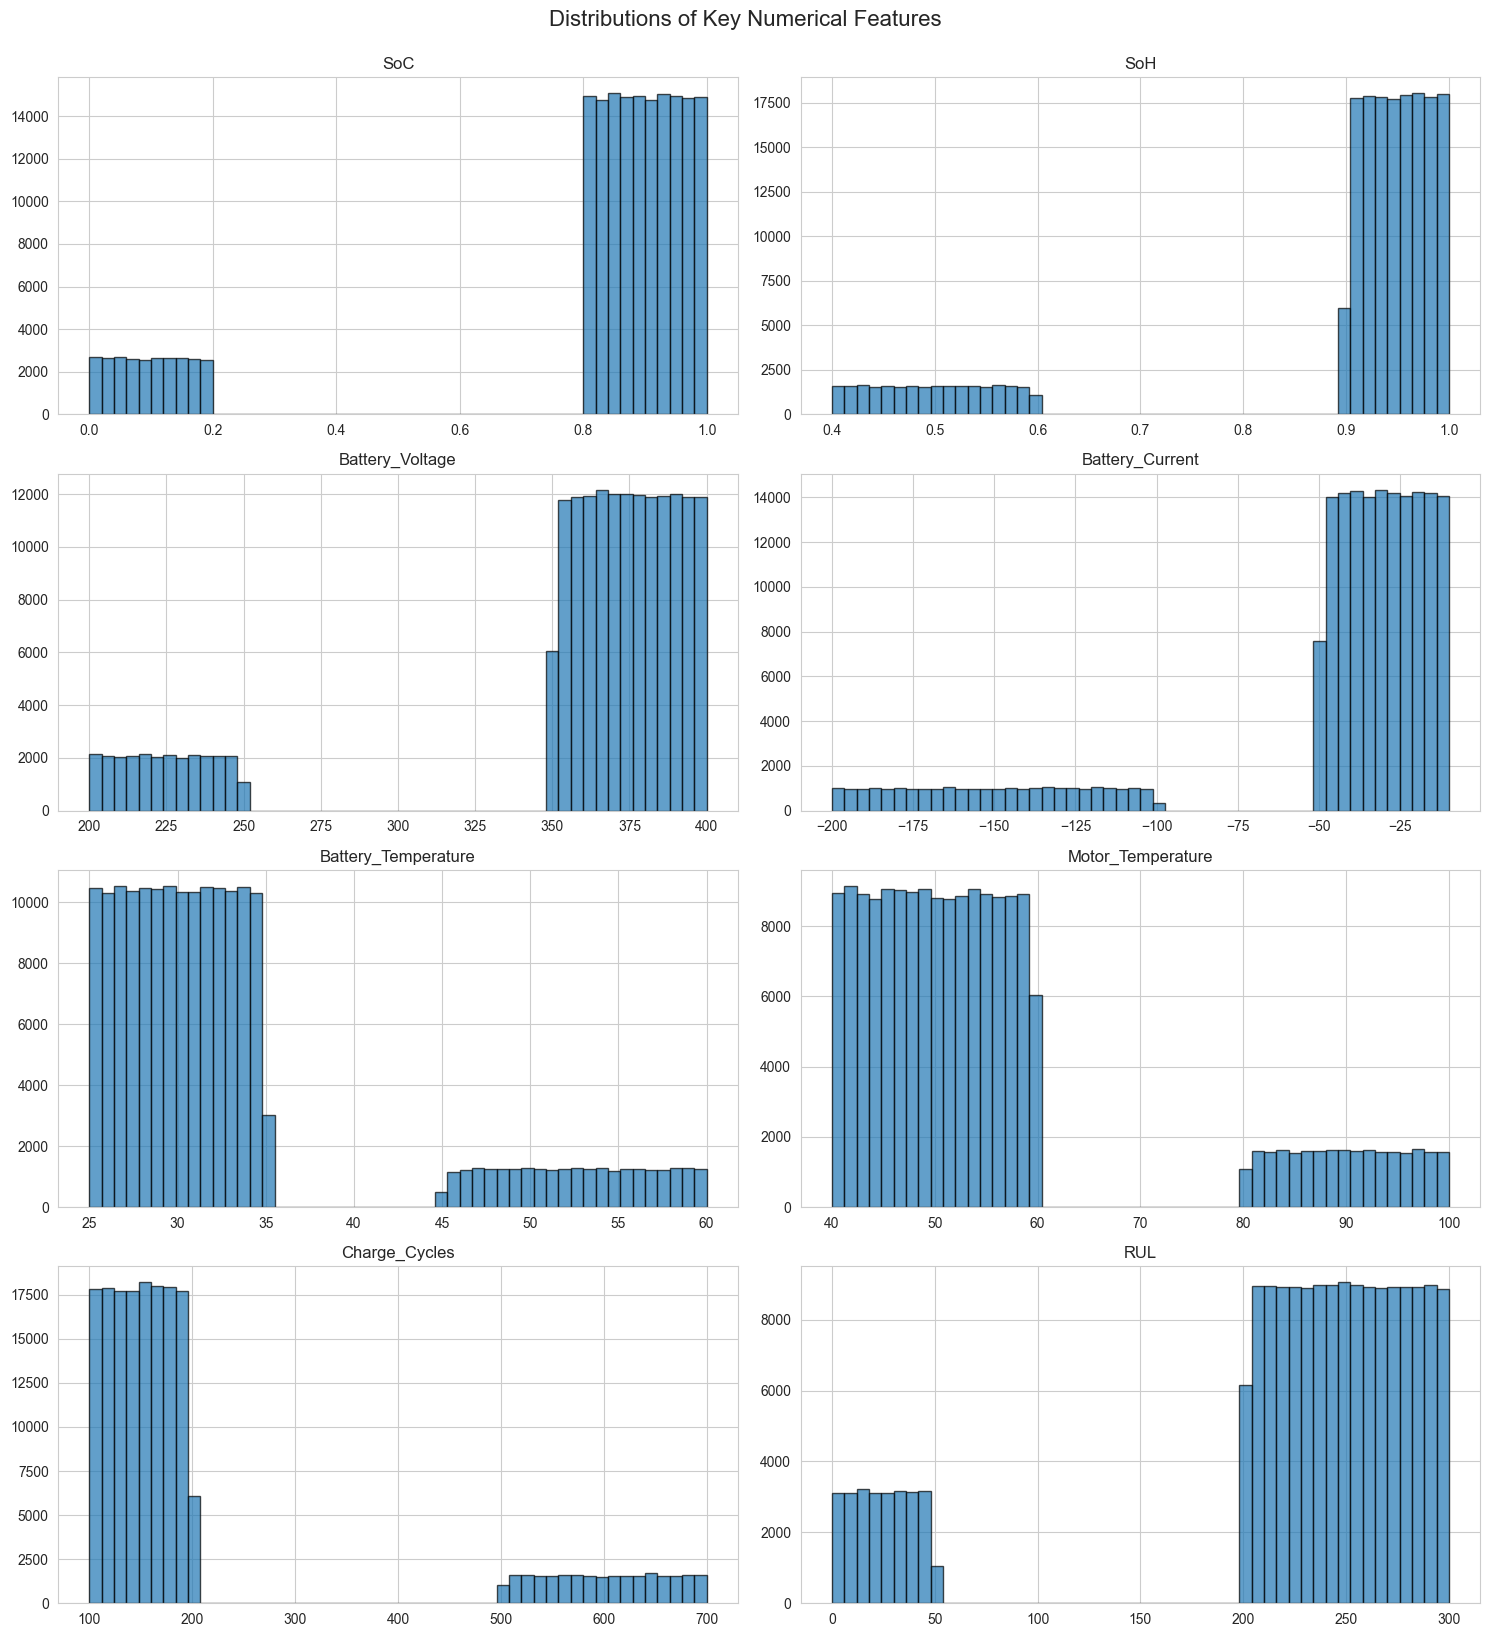

In [ ]:
# Univariate analysis: histograms of key continuous features
features_to_plot = ['SoC', 'SoH', 'Battery_Voltage', 'Battery_Current', 
                    'Battery_Temperature', 'Motor_Temperature', 'Charge_Cycles', 'RUL']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    ax = axes[i]
    df[col].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.suptitle('Distributions of Key Numerical Features', y=1.02, fontsize=16)
# plt.savefig('../output/distribution_histograms_for_Specific_Features.png')
plt.show()

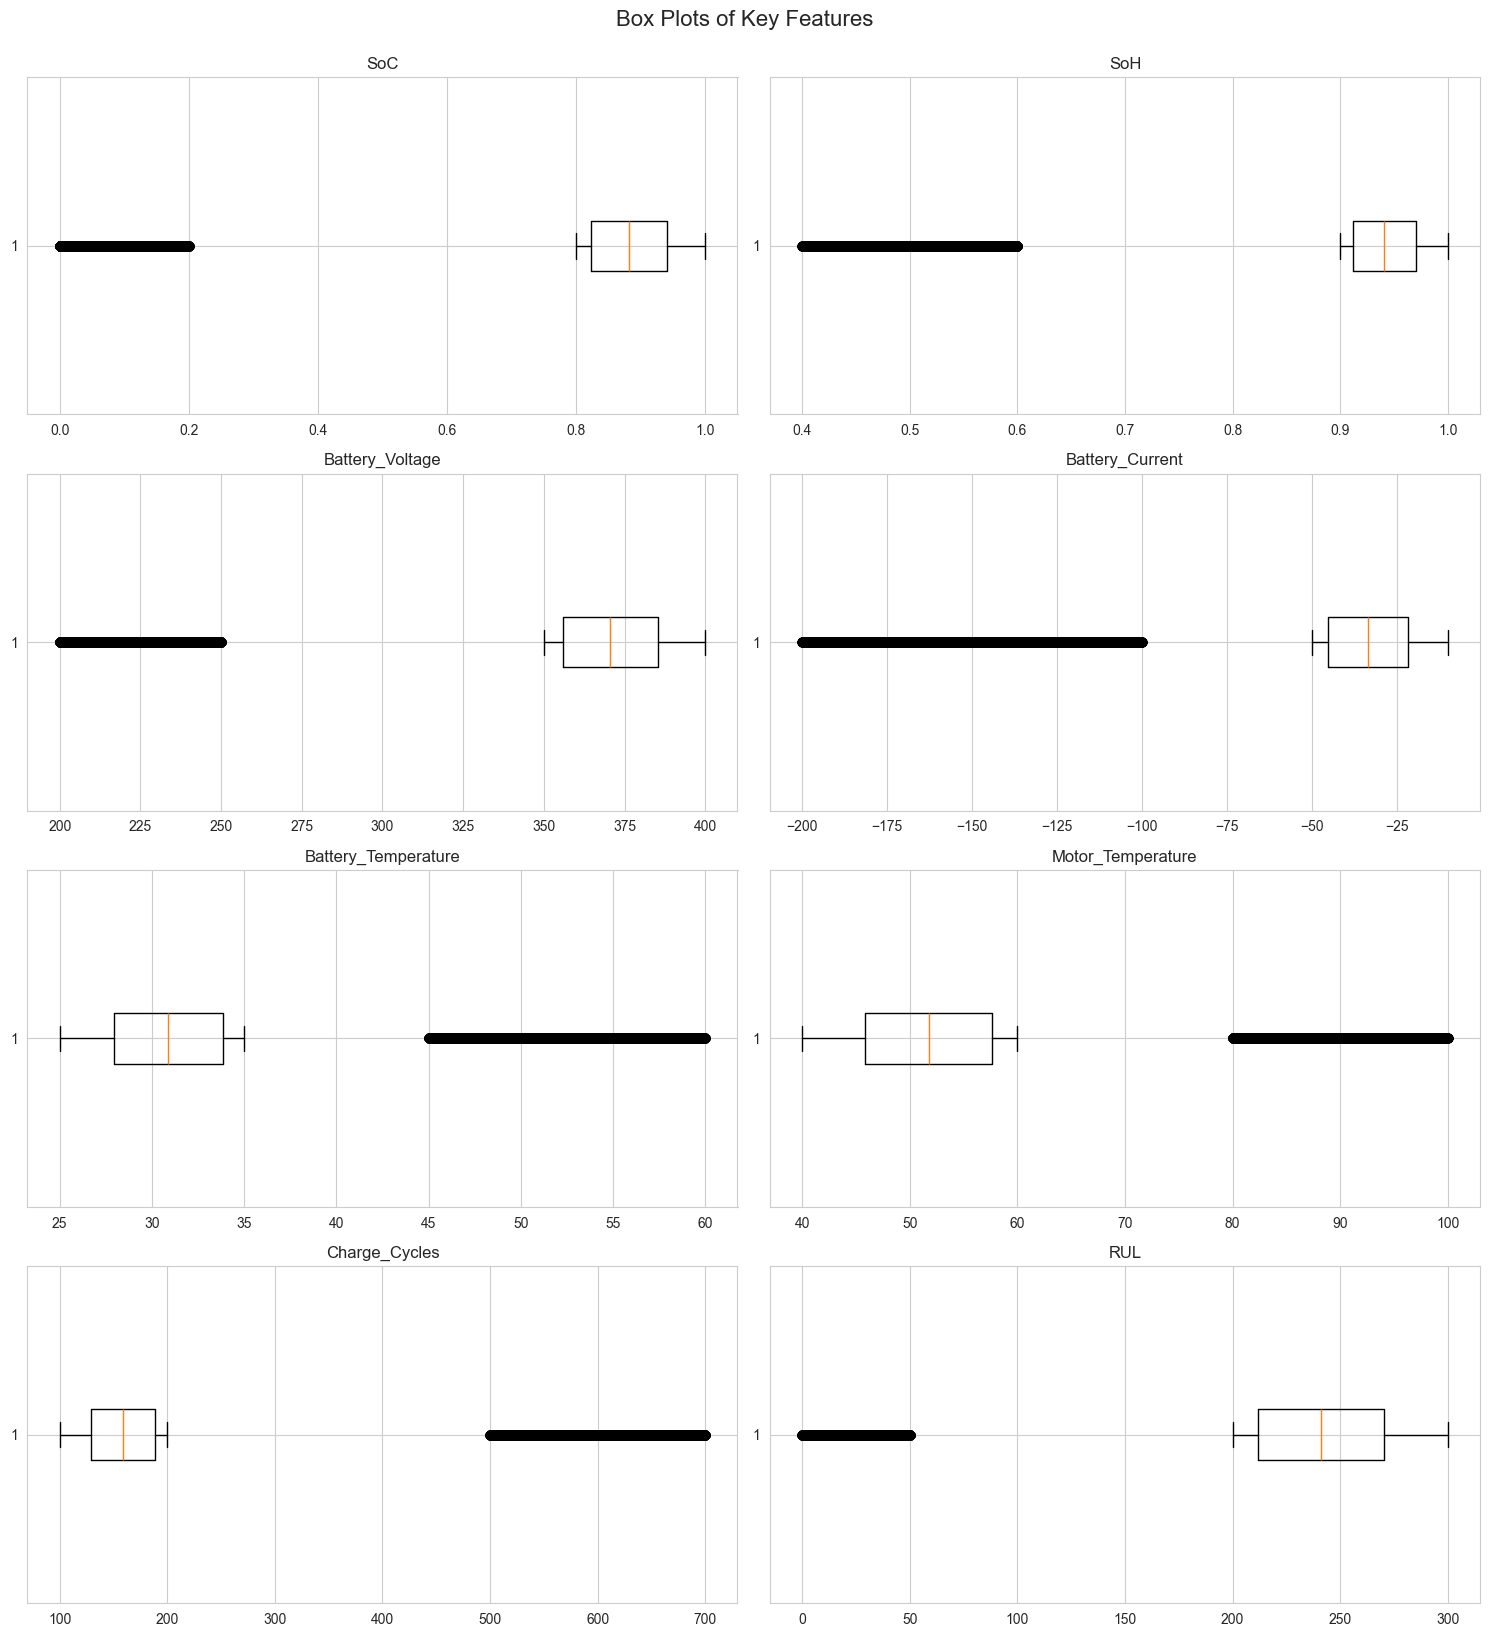

In [ ]:
# Boxplots for outlier detection
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(col)
plt.tight_layout()
plt.suptitle('Box Plots of Key Features', y=1.02, fontsize=16)
# plt.savefig('../output/box_plots_for_Specific_Features.png')
plt.show()

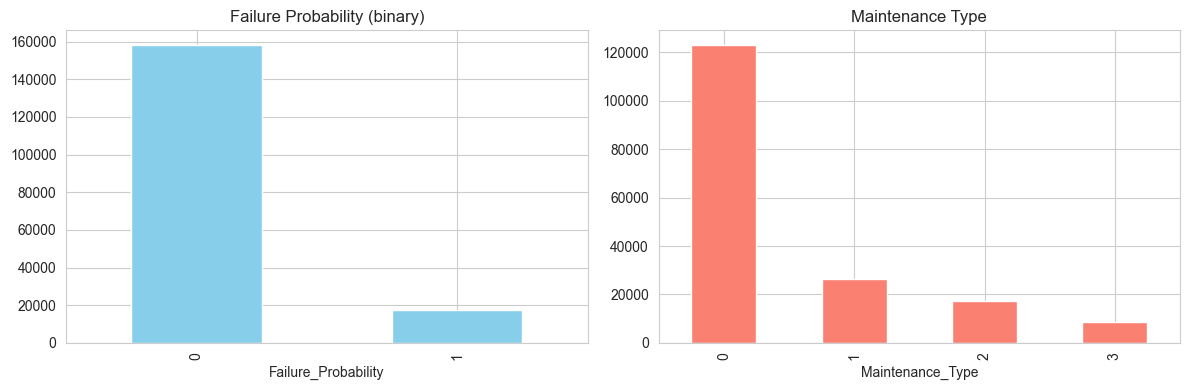

In [ ]:
# Categorical variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Failure_Probability'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Failure Probability (binary)')
df['Maintenance_Type'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Maintenance Type')
plt.tight_layout()
# plt.savefig('../output/categorical_distribution.png')
plt.show()

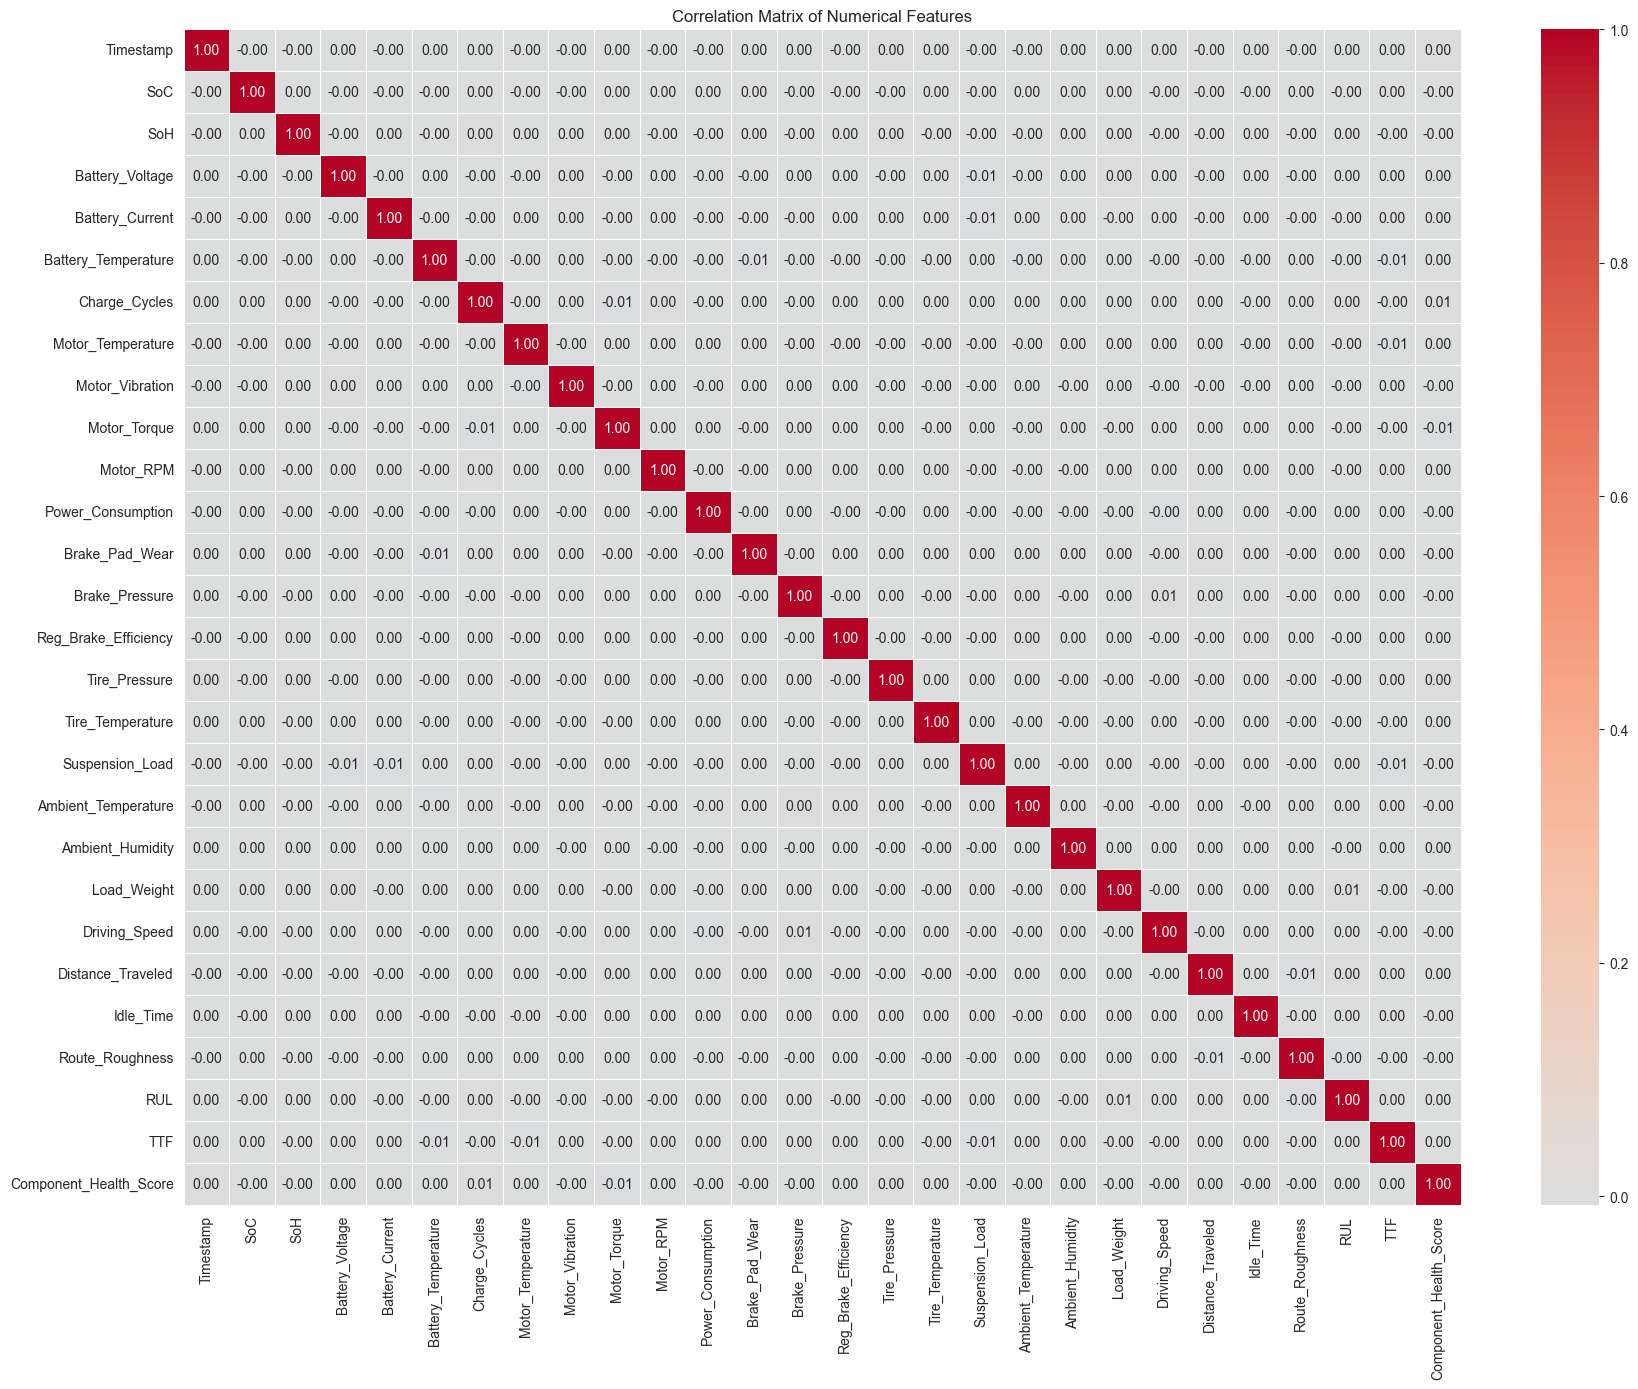

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(18, 14))
corr_matrix = df.drop(columns=['Failure_Probability', 'Maintenance_Type'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
# plt.savefig('../output/correlation_matrix.png')
plt.show()

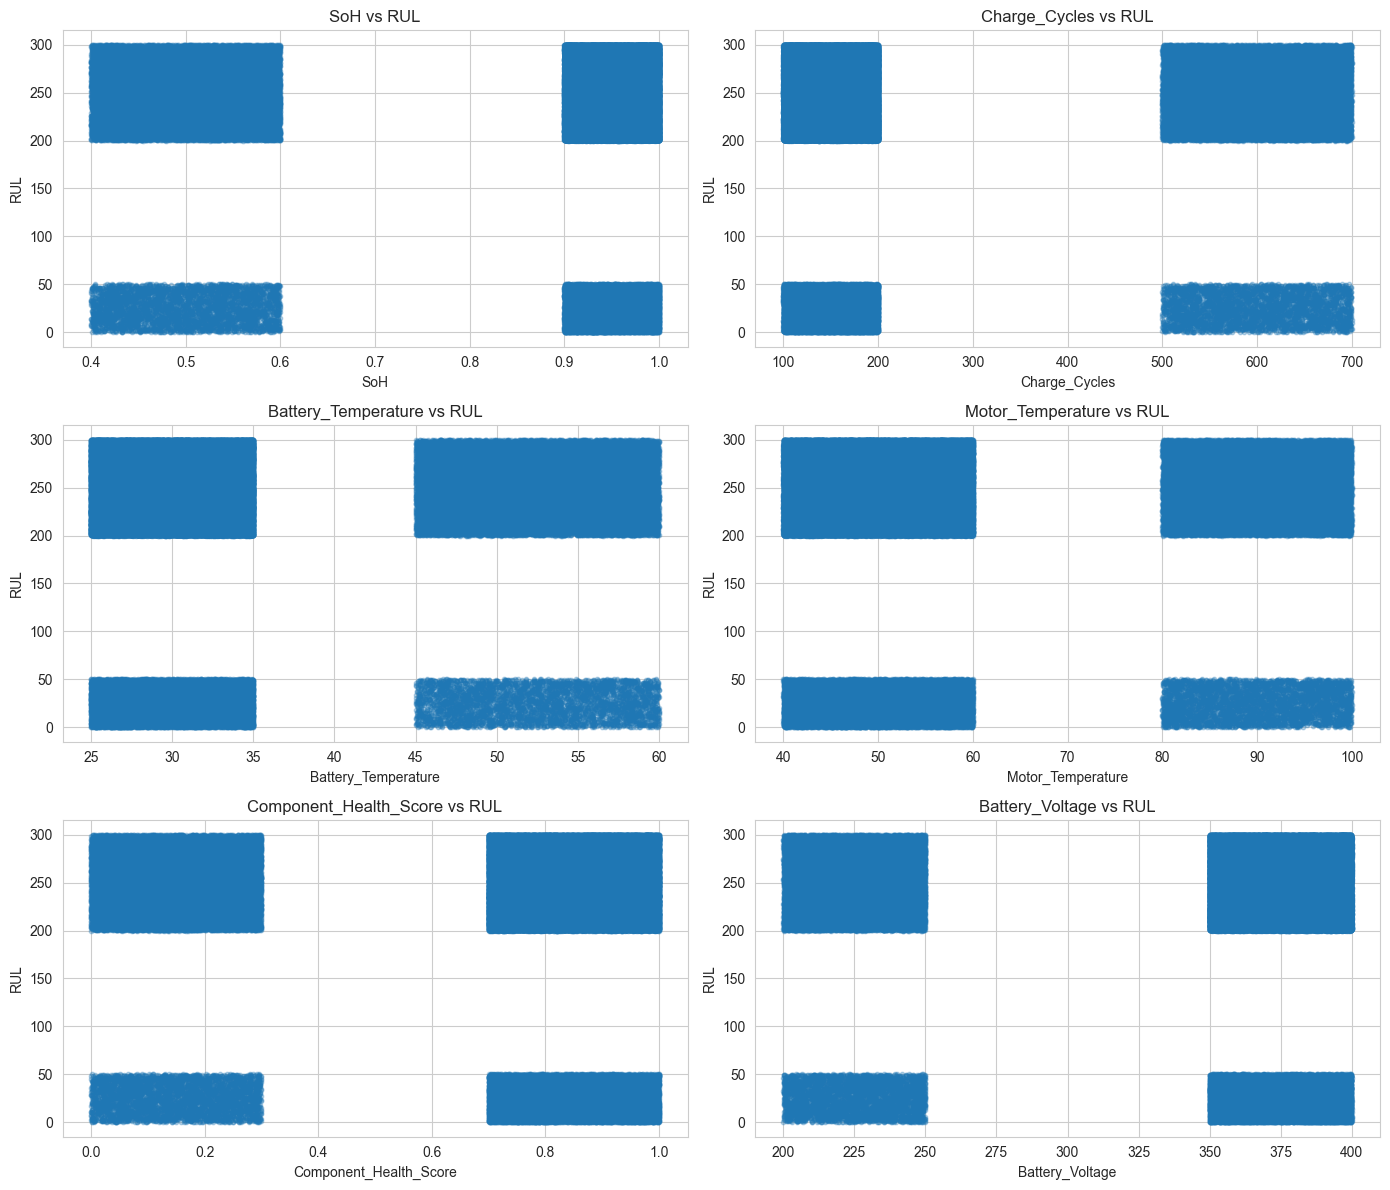

In [ ]:
# Bivariate relationships with RUL (target)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
target_col = 'RUL'
related_cols = ['SoH', 'Charge_Cycles', 'Battery_Temperature', 'Motor_Temperature', 'Component_Health_Score', 'Battery_Voltage']
for i, col in enumerate(related_cols):
    ax = axes[i//2, i%2]
    ax.scatter(df[col], df[target_col], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.set_title(f'{col} vs {target_col}')
plt.tight_layout()
# plt.savefig('../output/bivariate_relationships.png')
plt.show()

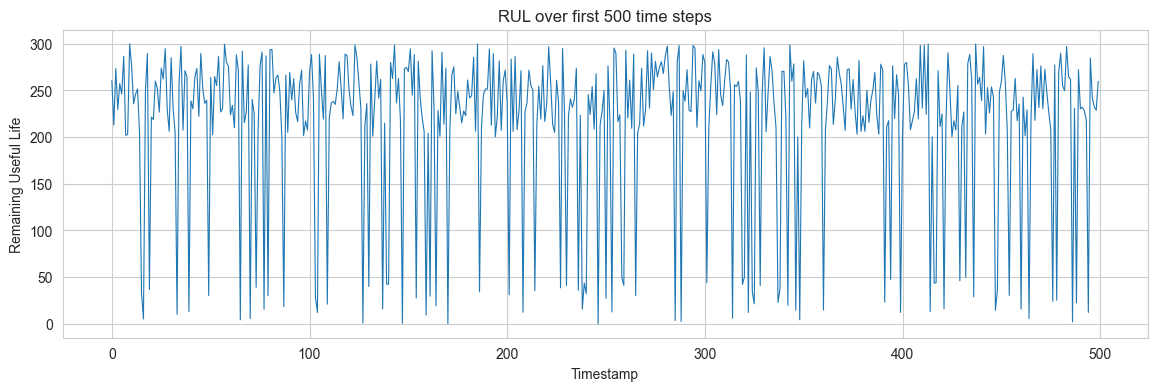

In [ ]:
# Time series example: RUL over the first few days
df_sorted = df.sort_index()
df_sorted['RUL'].head(500).plot(figsize=(14, 4), linewidth=0.8)
plt.title('RUL over first 500 time steps')
plt.ylabel('Remaining Useful Life')
plt.xlabel('Timestamp')
# plt.savefig('../output/rul_time_series.png')
plt.show()

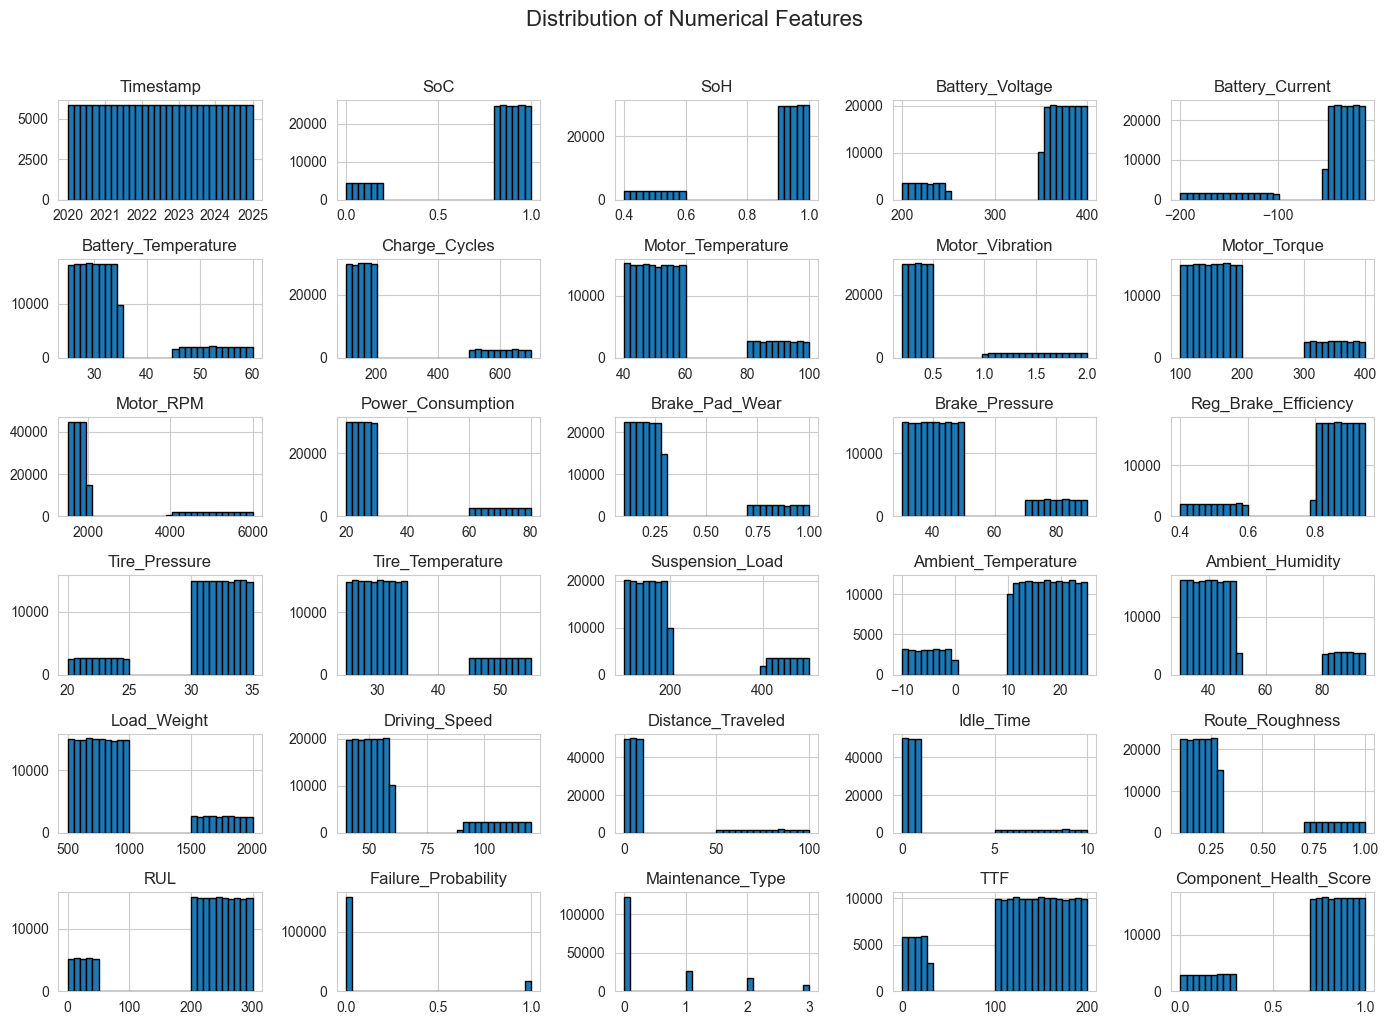

In [ ]:
df.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig('../output/distribution_histograms.png')
plt.show()

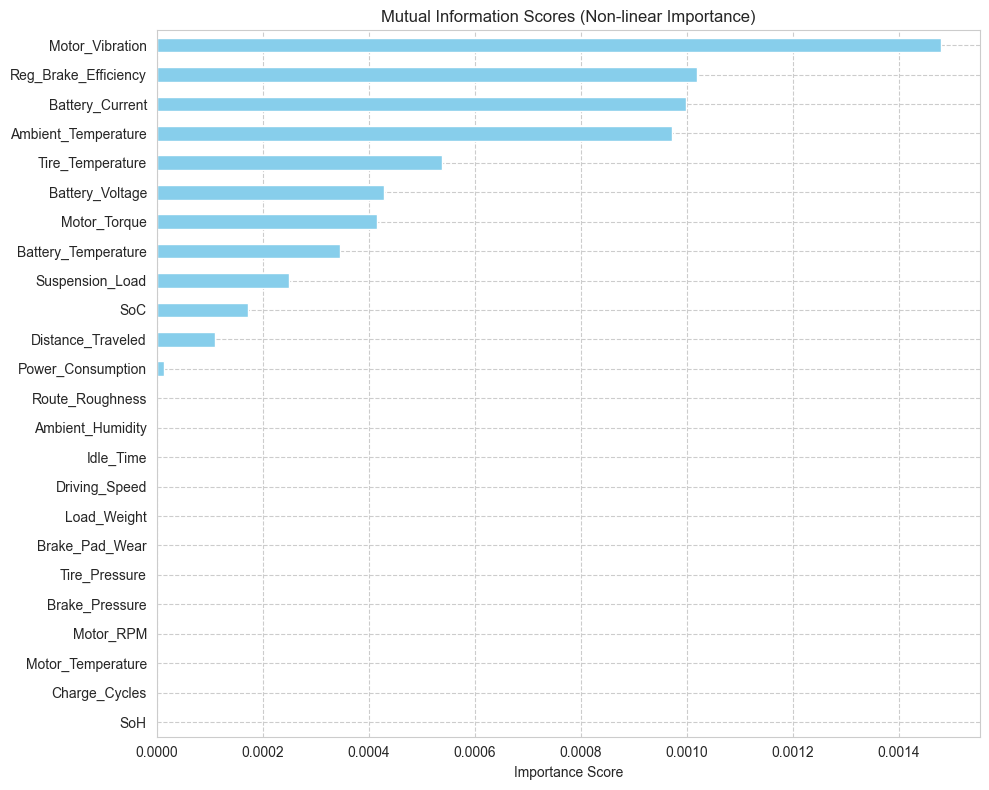

In [ ]:
# sample = df.sample(5000, random_state=42)
# X = sample.drop(columns=['Timestamp', 'Failure_Probability', 'Maintenance_Type', 'RUL', 'TTF', 'Component_Health_Score'])
# y = sample['Failure_Probability']

X = df.drop(columns=['Timestamp', 'Failure_Probability', 'Maintenance_Type', 'RUL', 'TTF', 'Component_Health_Score'])
y = df['Failure_Probability']

mi_scores = mutual_info_classif(X, y)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
mi_series.plot(kind='barh', color='skyblue')
plt.title('Mutual Information Scores (Non-linear Importance)')
plt.xlabel('Importance Score')
plt.grid(axis='both', linestyle='--')
plt.tight_layout()
# plt.savefig('../output/mutual_info_plot.png')
plt.show()

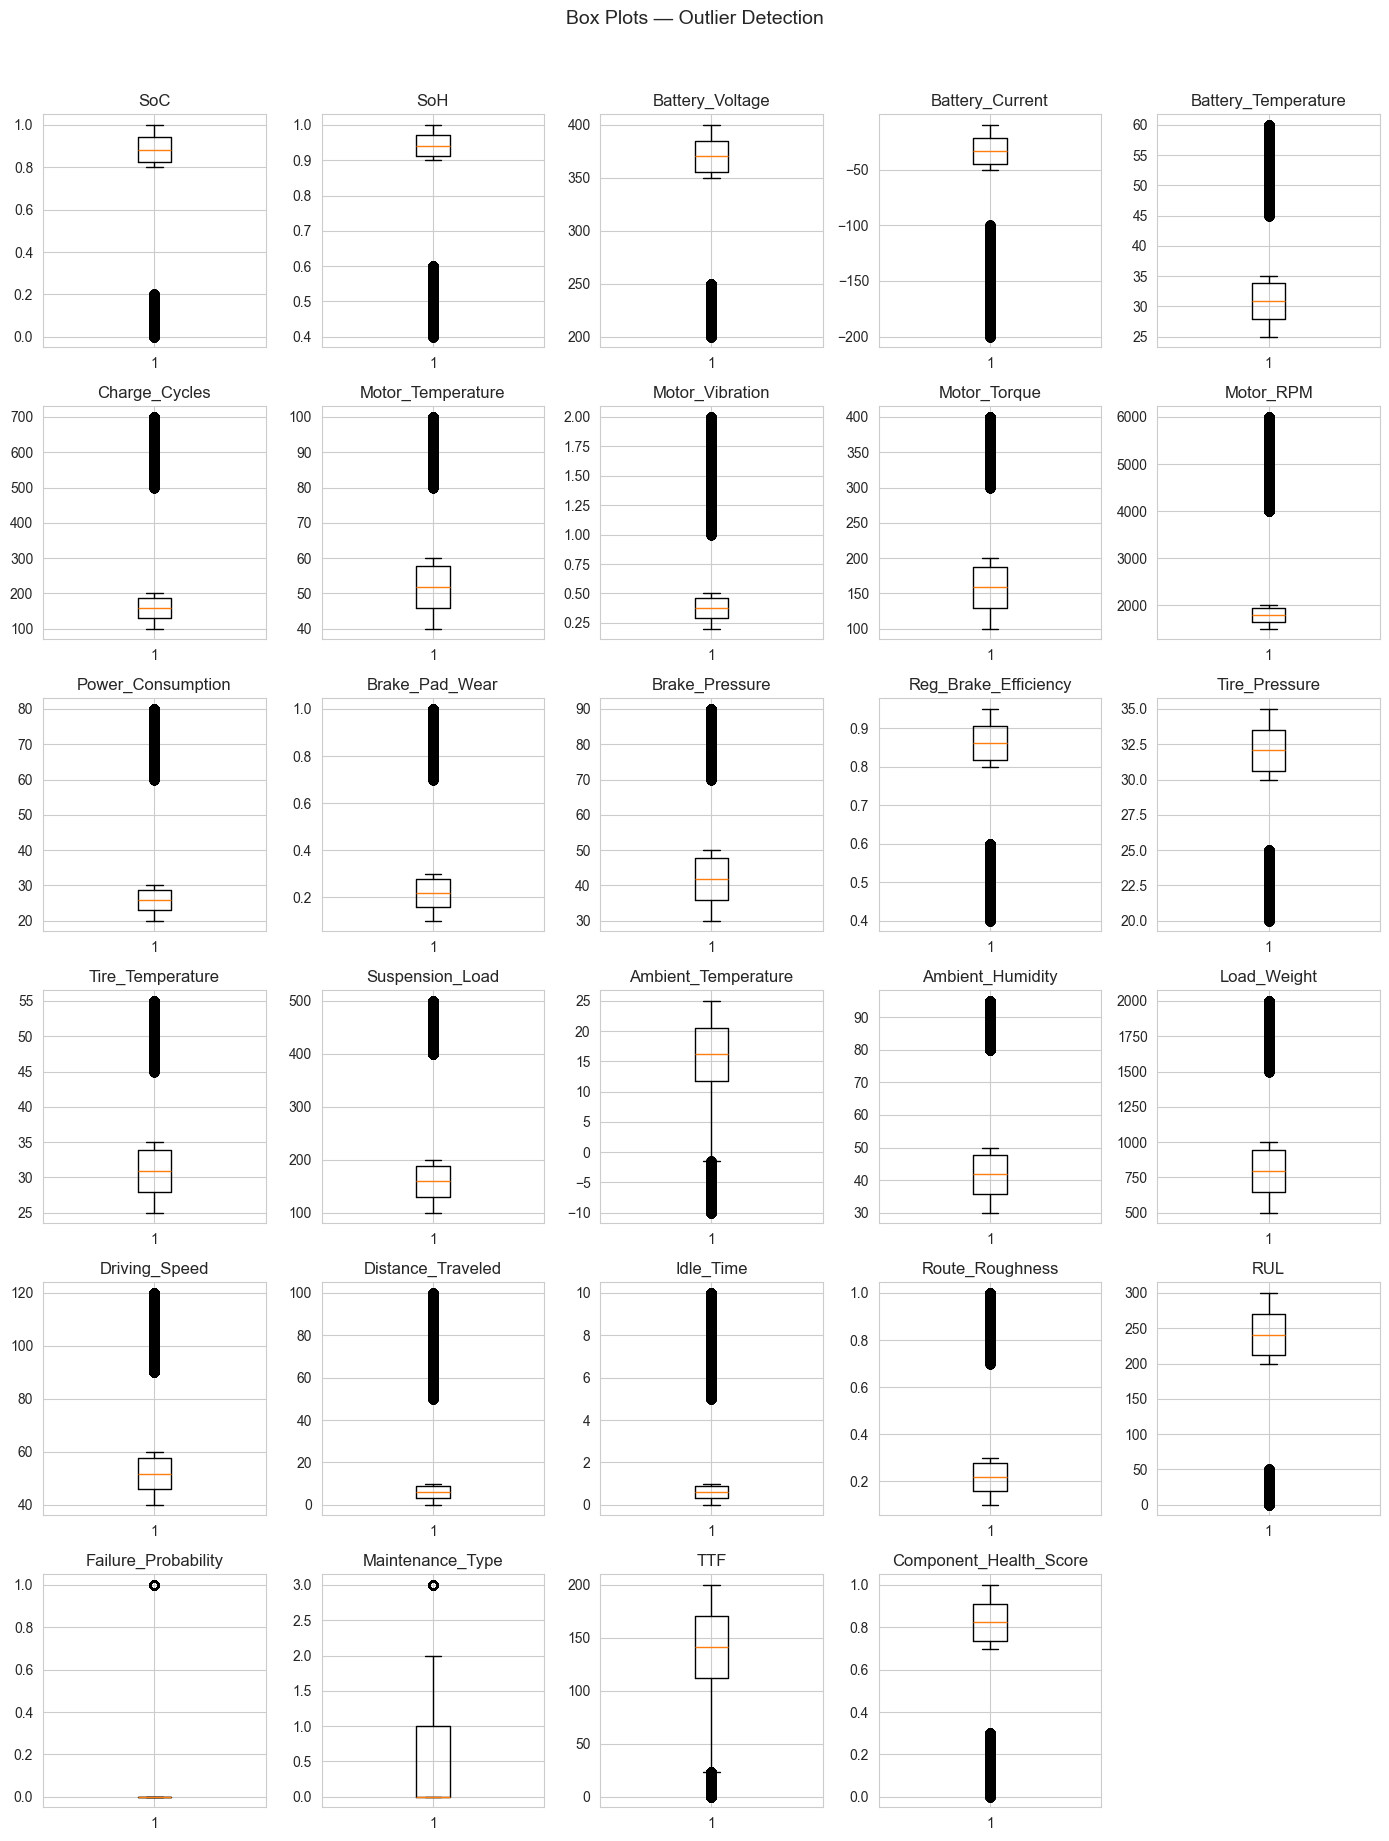

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if numerical_cols:
    n_cols = 5
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 18))
    
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    
    for ax, col in zip(axes, numerical_cols):
        ax.boxplot(df[col].dropna())
        ax.set_title(col)
    
    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
    plt.tight_layout()
    # plt.savefig('../output/box_plots.png')
    plt.show()

**Initial Insights & Hypotheses:**
1. **Relationships** No linear relation between features and target variable, but there are some non-linear relationships.
2. **Motor_Vibration** is the most important feature for predicting Failure_Probability.
3. **SoH tends to decrease with increasing Charge_Cycles**, as expected from battery degradation.
4. **RUL is positively correlated with SoH and Component_Health_Score**, and negatively correlated with Charge_Cycles.
5. **Battery_Current** shows extreme values that might indicate fast charging/discharging events.
6. **Maintenance_Type** appears somewhat related to Failure_Probability; types 1-3 may be associated with different failure modes.
7. **Some features exhibit seasonal-like variation** (e.g., battery temperature), likely due to ambient conditions or driving patterns.
8. **Hypothesis**: The combination of SoH, Charge_Cycles, Motor_Temperature, and Battery_Temperature could be strong predictors of RUL.

---
### Task 4: Verify Data Quality

Check for missing values, duplicates, outliers, and inconsistencies.

In [16]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_report) == 0:
    print("No missing values detected in any column.")
else:
    print("=== Missing Values Report ===")
    print(missing_report)

No missing values detected in any column.


In [17]:
# Duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [18]:
# Outlier detection using Z-score for ALL numerical columns
num_cols = df.select_dtypes(include=np.number).columns
outlier_summary = []

for col in num_cols:
    # Drop NaN just in case (though none exist)
    col_data = df[col].dropna()
    # Calculate Z-scores (ignoring any potential inf from constant columns)
    z = np.abs(stats.zscore(col_data))
    outlier_count = (z > 3).sum()
    outlier_pct = (outlier_count / len(col_data)) * 100
    outlier_summary.append([col, outlier_count, outlier_pct])

outlier_df = pd.DataFrame(outlier_summary, columns=['Column', 'Outlier Count', 'Outlier %'])
outlier_df = outlier_df.sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

                Column  Outlier Count  Outlier %
   Failure_Probability          17332     9.8818
       Motor_Vibration           4583     2.6130
       Battery_Current           4124     2.3513
     Distance_Traveled           3947     2.2504
             Idle_Time           3720     2.1210
             Motor_RPM           2626     1.4972
   Battery_Temperature           1122     0.6397
                   SoH              0     0.0000
         Charge_Cycles              0     0.0000
          Motor_Torque              0     0.0000
       Battery_Voltage              0     0.0000
     Motor_Temperature              0     0.0000
                   SoC              0     0.0000
        Brake_Pressure              0     0.0000
        Brake_Pad_Wear              0     0.0000
     Power_Consumption              0     0.0000
  Reg_Brake_Efficiency              0     0.0000
   Ambient_Temperature              0     0.0000
         Tire_Pressure              0     0.0000
      Tire_Temperatu

In [19]:
# Data type consistency
print("Data types:")
print(df.dtypes)

# Check for negative values in fields that should be non-negative
non_neg_cols = ['SoC', 'SoH', 'Charge_Cycles', 'RUL', 'TTF', 'Component_Health_Score', 'Failure_Probability']
neg_counts = {col: (df[col] < 0).sum() for col in non_neg_cols if col in df.columns}
neg_report = {col: cnt for col, cnt in neg_counts.items() if cnt > 0}
if neg_report:
    print("\nColumns with negative values (unexpected):", neg_report)
else:
    print("\nNo unexpected negative values in constrained columns.")

Data types:
Timestamp                 datetime64[ns]
SoC                              float64
SoH                              float64
Battery_Voltage                  float64
Battery_Current                  float64
Battery_Temperature              float64
Charge_Cycles                    float64
Motor_Temperature                float64
Motor_Vibration                  float64
Motor_Torque                     float64
Motor_RPM                        float64
Power_Consumption                float64
Brake_Pad_Wear                   float64
Brake_Pressure                   float64
Reg_Brake_Efficiency             float64
Tire_Pressure                    float64
Tire_Temperature                 float64
Suspension_Load                  float64
Ambient_Temperature              float64
Ambient_Humidity                 float64
Load_Weight                      float64
Driving_Speed                    float64
Distance_Traveled                float64
Idle_Time                        float64
Rout

**Data Quality Summary:**
- The dataset is complete: no missing values detected.
- No duplicate rows found.
- Some features like Battery_Current and Brake_Pressure show extreme values (potential outliers), likely representing real physical events (e.g., regenerative braking, high loads). These may be kept for modeling but should be investigated.
- All data types are appropriate; timestamps are regular (15-min intervals). No gaps detected.
- The synthetic nature of the data ensures there are no formatting or consistency issues.